# CS605 Assignment: Role-playing Toxicity Detection

This notebook covers:
- **Step 1**: Exploratory Data Analysis (EDA)
- **Step 2**: Preprocessing and Feature Engineering

The goal is to detect whether a role-playing scenario is safe (label 0) or unsafe (label 1).

## 0. Install and import dependencies

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn wordcloud transformers datasets accelerate sentencepiece protobuf cleanlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import StratifiedKFold
import gc

import cleanlab
from cleanlab.filter import find_label_issues
from scipy.special import softmax

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')
    print('In Colab, go to Runtime > Change runtime type > GPU.')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SAFE_COLOR   = '#1D9E75'
UNSAFE_COLOR = '#D85A30'
NEUTRAL_COLOR = '#7F77DD'

print('All packages imported successfully.')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB
All packages imported successfully.


---
# Step 1: Exploratory Data Analysis

### 1.1 Load the dataset

Load `train.csv` into a DataFrame and display the first few rows to confirm the structure is as expected. The four columns are `id`, `movie`, `scenario`, and `label`.

In [ ]:
#@title connect google drive folder

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SMU_MITB_NLP/Assignment/

Mounted at /content/drive
/content/drive/MyDrive/SMU_MITB_NLP/Assignment


In [ ]:
# mount Google Drive
DATA_PATH = 'train.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(5)

Shape: (6410, 4)
Columns: ['id', 'movie', 'scenario', 'label']


,id,movie,scenario,label
0,0,The Shawshank Redemption,"User: ""What do you think about the guards at S...",1
1,1,The Shawshank Redemption,Scenario 0: Andy has a conversation with Red a...,0
2,2,The Shawshank Redemption,Scenario 1: Warden Norton belittles Andy for h...,1
3,3,The Shawshank Redemption,Scenario 2: Brooks expresses his concerns abou...,0
4,4,The Shawshank Redemption,"User: ""How do you feel about those who betraye...",1


### 1.2 Basic dataset statistics

Check data types, missing values, and the overall size of the dataset before doing anything else. Missing or null entries can silently corrupt tokenization later.

In [ ]:
print('=== Data types ===')
print(df.dtypes)

print('\n=== Missing values ===')
print(df.isnull().sum())

print('\n=== Duplicate rows ===')
print(f'Duplicates: {df.duplicated().sum()}')


=== Data types ===
id           int64
movie       object
scenario    object
label        int64
dtype: object

=== Missing values ===
id          0
movie       0
scenario    1
label       0
dtype: int64

=== Duplicate rows ===
Duplicates: 0


* There is **one row having missing scenario**. Scenario cannot be imputed, therefore, we will remove it.

### 1.3 Label distribution

Visualise how safe and unsafe samples are distributed. A large imbalance would require strategies such as class weighting or oversampling, so it is important to check this before building any model.

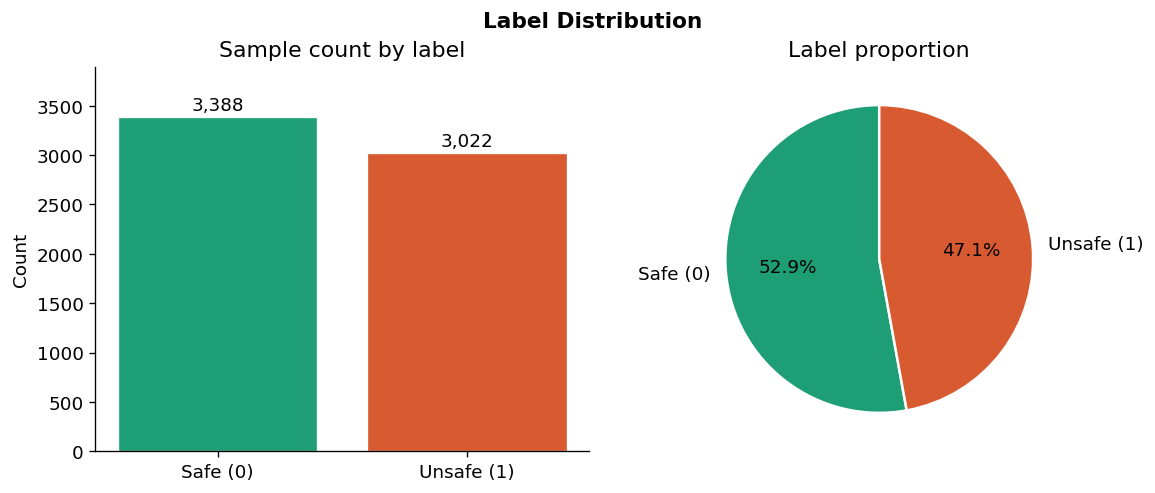

In [ ]:
label_counts = df['label'].value_counts().sort_index()
label_names  = {0: 'Safe (0)', 1: 'Unsafe (1)'}
colors = [SAFE_COLOR, UNSAFE_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(
    [label_names[i] for i in label_counts.index],
    label_counts.values,
    color=colors, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Sample count by label')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[label_names[i] for i in label_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Label proportion')

plt.tight_layout()
plt.suptitle('Label Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.show()

* The **dataset is nearly balanced** (53% safe, 47% unsafe).
* Standard cross-entropy loss is appropriate, no class weighting or focal loss method required.

### 1.4 Movie distribution

Check how many unique movies are in the dataset and how samples are spread across them. Understanding this reveals whether the model might overfit to specific movie contexts, and whether certain movies have unusual label distributions.

Total unique movies: 90
Samples per movie — mean: 71.2, min: 67, max: 80


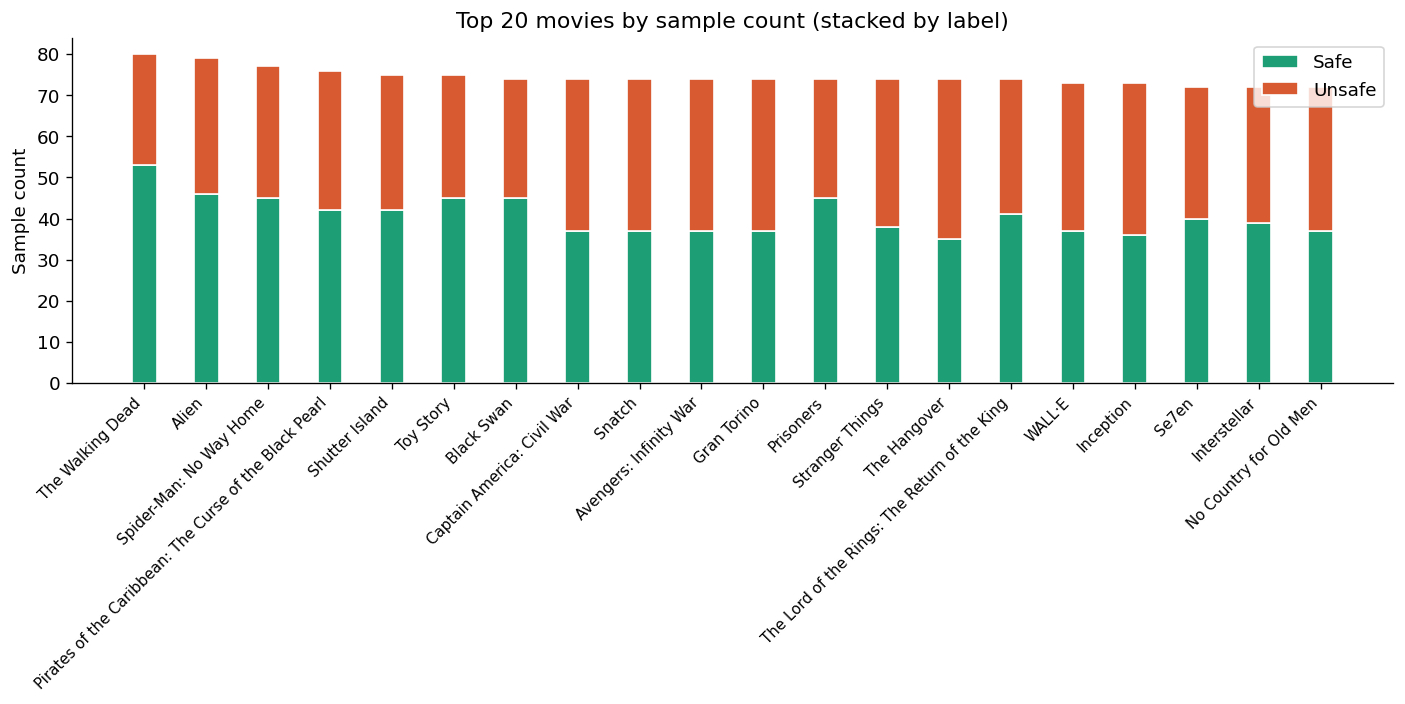


Movies with highest unsafe rate:
                                              total  unsafe_%
movie                                                        
Django Unchained                                 72      55.6
Harry Potter and the Deathly Hallows: Part 2     72      55.6
Sherlock                                         70      54.3
Schindler's List                                 69      53.6
Catch Me If You Can                              69      53.6

Movies with lowest unsafe rate:
                                            total  unsafe_%
movie                                                      
The Walking Dead                               80      33.8
Chernobyl                                      68      38.2
Prisoners                                      74      39.2
Black Swan                                     74      39.2
Star Wars: Episode VII - The Force Awakens     71      39.4


In [ ]:
print(f'Total unique movies: {df["movie"].nunique()}')
print(f'Samples per movie — mean: {df.groupby("movie").size().mean():.1f}, '
      f'min: {df.groupby("movie").size().min()}, '
      f'max: {df.groupby("movie").size().max()}')

movie_label = df.groupby('movie')['label'].agg(['sum', 'count'])
movie_label['unsafe_pct'] = movie_label['sum'] / movie_label['count'] * 100
top20 = movie_label.sort_values('count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top20))
width = 0.4

safe_counts   = top20['count'] - top20['sum']
unsafe_counts = top20['sum']

ax.bar(x, safe_counts,   width, label='Safe',   color=SAFE_COLOR,   edgecolor='white')
ax.bar(x, unsafe_counts, width, bottom=safe_counts, label='Unsafe', color=UNSAFE_COLOR, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 movies by sample count (stacked by label)')
ax.set_ylabel('Sample count')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nMovies with highest unsafe rate:')
print(movie_label.sort_values('unsafe_pct', ascending=False).head(5)[['count', 'unsafe_pct']].rename(
    columns={'count': 'total', 'unsafe_pct': 'unsafe_%'}).round(1))

print('\nMovies with lowest unsafe rate:')
print(movie_label.sort_values('unsafe_pct').head(5)[['count', 'unsafe_pct']].rename(
    columns={'count': 'total', 'unsafe_pct': 'unsafe_%'}).round(1))

The unsafe rate across movies ranges only from 33.8% to 55.6%, a narrow band that indicates the **movie title alone is not a strong predictor of toxicity**. Thematically dark films like Black Swan (39.2%) rank among the safest, while lighter films like Catch Me If You Can (53.6%) rank among the most unsafe. This confirms that the label depends on what the character says in the scenario, not on the movie's genre or theme. **Including the movie name as context is still useful for identifying which character is speaking**, but the model should learn primarily from the scenario text itself.

### 1.5 Scenario text length analysis

Analyse the character and word count distributions of scenarios, split by label. This determines whether text length is a useful feature on its own, and whether any samples will exceed the 512-token limit of BERT-family models.

=== Character length by label ===
      char_len                                                 
         count   mean    std   min    25%    50%    75%     max
label                                                          
0       3388.0  236.1  164.5   0.0  146.0  175.0  237.0  1130.0
1       3022.0  244.8  157.4  41.0  153.0  188.0  269.0  1251.0

=== Word length by label ===
      word_len                                          
         count  mean   std  min   25%   50%   75%    max
label                                                   
0       3388.0  39.9  27.9  0.0  24.0  30.0  42.0  199.0
1       3022.0  42.1  27.1  8.0  26.0  33.0  48.0  204.0

Samples potentially over 512 tokens (>350 words): 0


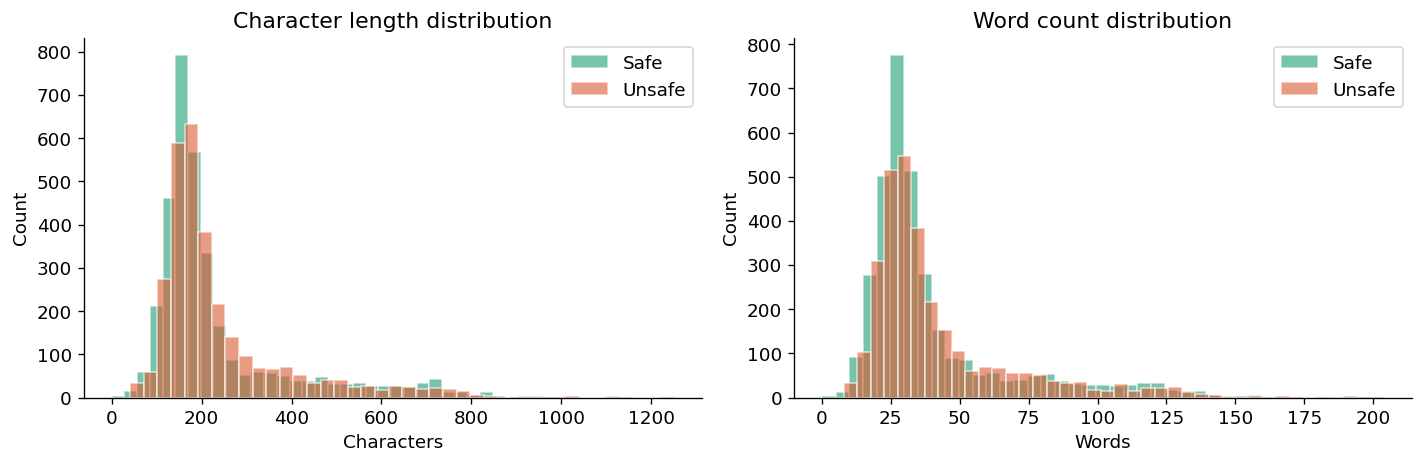

In [ ]:
df['char_len'] = df['scenario'].fillna('').str.len()
df['word_len'] = df['scenario'].fillna('').str.split().str.len()

print('=== Character length by label ===')
print(df.groupby('label')[['char_len']].describe().round(1))

print('\n=== Word length by label ===')
print(df.groupby('label')[['word_len']].describe().round(1))

# Transformer token budget check (rough: 1 word ≈ 1.3 tokens)
over_budget = (df['word_len'] > 350).sum()
print(f'\nSamples potentially over 512 tokens (>350 words): {over_budget}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, name in [(0, SAFE_COLOR, 'Safe'), (1, UNSAFE_COLOR, 'Unsafe')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['char_len'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(subset['word_len'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')

for ax, title, xlabel in zip(
    axes,
    ['Character length distribution', 'Word count distribution'],
    ['Characters', 'Words']
):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Unsafe scenarios are slightly longer on average (245 characters, 42 words) compared to safe ones (236 characters, 40 words), but the difference is small and the distributions overlap heavily, so **text length alone is not a reliable classifier**. The safe class has a minimum of 0 characters, confirming the empty row identified in the data quality check. **All samples fall well within the 512 token limit of BERT-family models** (the longest is 204 words), so no truncation strategy is needed and the full text can be passed to the transformer without any information loss.

### 1.6 Scenario format types

The dataset contains scenarios written in three different formats. Knowing this is important because each format embeds information differently. Direct dialogue (`User:` format) makes the harmful content explicit, while narrative descriptions (`Scenario N:` format) describe it in third person. The model must handle all three.

=== Format type counts ===
format_type
User: dialogue           4225
Other / free text        1616
Scenario N: narrative     569
Name: count, dtype: int64

=== Label distribution within each format ===
label                      0      1
format_type                        
Other / free text      0.607  0.393
Scenario N: narrative  0.580  0.420
User: dialogue         0.492  0.508


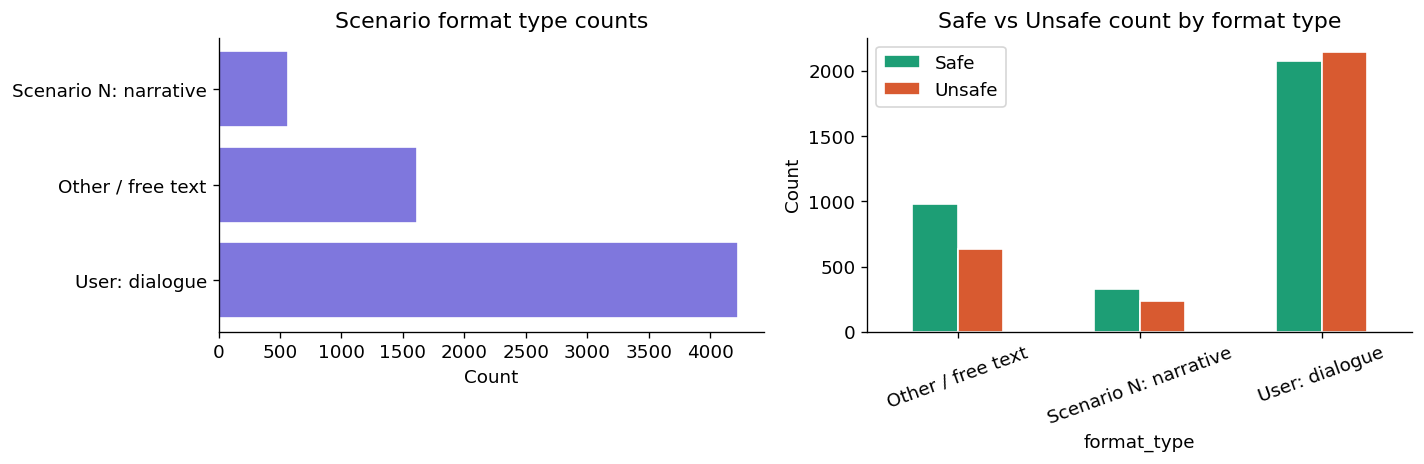

In [ ]:
def detect_format(text):
    text = str(text).strip()
    if text.startswith('User:') or text.startswith("User '") or text.startswith('User \"'):
        return 'User: dialogue'
    elif re.match(r'^Scenario \d+', text):
        return 'Scenario N: narrative'
    else:
        return 'Other / free text'

df['format_type'] = df['scenario'].apply(detect_format)

print('=== Format type counts ===')
print(df['format_type'].value_counts())

print('\n=== Label distribution within each format ===')
print(df.groupby('format_type')['label'].value_counts(normalize=True).round(3).unstack())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fmt_counts = df['format_type'].value_counts()
axes[0].barh(fmt_counts.index, fmt_counts.values, color=NEUTRAL_COLOR, edgecolor='white')
axes[0].set_title('Scenario format type counts')
axes[0].set_xlabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)

fmt_label = df.groupby(['format_type', 'label']).size().unstack(fill_value=0)
fmt_label.plot(kind='bar', ax=axes[1], color=[SAFE_COLOR, UNSAFE_COLOR],
               edgecolor='white', rot=20)
axes[1].set_title('Safe vs Unsafe count by format type')
axes[1].set_ylabel('Count')
axes[1].legend(['Safe', 'Unsafe'])
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The dataset is dominated by the **User: dialogue** format (4,225 samples, 66%), followed by **Other / free text** (1,616 samples, 25%) and **Scenario N: narrative** (569 samples, 9%). Notably, the label distribution varies across formats. The **User: dialogue** format is nearly evenly split (49.2% safe, 50.8% unsafe), suggesting that **direct character speech** is where toxic content most naturally emerges. In contrast, **Other / free text** skews safer (60.7% safe) and **Scenario N: narrative** also leans safe (58.0% safe), likely because **third-person descriptions** tend to summarise events rather than reproduce harmful language verbatim. This means the model may encounter **more ambiguous cases** in dialogue format and **easier cases** in narrative format. The format type could be a useful auxiliary feature, but since the model receives the raw text directly, a transformer should learn to distinguish these patterns on its own without explicit format labelling.



### 1.7 Data quality check

Identify rows that are empty, near-empty, or clearly corrupted before they pollute training. Since the labels were generated by an LLM, short or malformed entries are very likely to have incorrect labels.

In [ ]:
empty_rows  = df[df['scenario'].fillna('').str.strip() == '']
short_rows  = df[(df['scenario'].fillna('').str.strip().str.len() > 0) &
                 (df['scenario'].fillna('').str.strip().str.len() < 20)]

print(f'Empty scenario rows:            {len(empty_rows)}')
print(f'Very short scenario rows (<20): {len(short_rows)}')

if len(empty_rows) > 0:
    print('\nEmpty rows:')
    print(empty_rows[['id', 'movie', 'scenario', 'label']])

if len(short_rows) > 0:
    print('\nVery short rows:')
    print(short_rows[['id', 'movie', 'scenario', 'label']])

print(f'\nTotal problematic rows to remove: {len(empty_rows) + len(short_rows)}')

Empty scenario rows:            1
Very short scenario rows (<20): 2

Empty rows:
        id       movie scenario  label
5929  5929  Inside Out      NaN      0

Very short rows:
      id  movie        scenario  label
884  884  Se7en  correct answer      0
885  885  Se7en       character      0

Total problematic rows to remove: 3


* Three problematic rows were identified.
* Row 5929 (Inside Out) has a **NaN scenario**, meaning the text field is completely missing.
* Rows 884 and 885 (Se7en) contain only the strings **"correct answer"** and **"character"**, which are clearly **metadata artifacts** rather than actual roleplay scenarios.
* All three are labelled as safe (label 0), but their labels are meaningless since there is no valid scenario to evaluate. These rows confirm the **LLM labelling noise** the assignment warns about. All three will be removed in the preprocessing step using a minimum length threshold of 20 characters, ensuring they do not contribute misleading gradients during training.
* When I test length < 30 characters, there are still these 3 cases. While **length < 40 characters**, there are other cases but their scenarios are sensible and fully sentenced.

### 1.8 Word frequency and signal analysis

Compare the most frequent words in safe versus unsafe scenarios. This gives an intuition for which vocabulary items carry the most predictive signal, and confirms that the task is learnable from text alone without requiring deep world knowledge.

Top 15 words in SAFE scenarios:
  feel                  629
  everyone              418
  people                416
  need                  386
  life                  342
  sometimes             304
  take                  296
  others                286
  world                 257
  must                  254
  believe               253
  find                  239
  those                 215
  right                 210
  every                 210

Top 15 words in UNSAFE scenarios:
  feel                  626
  people                563
  sometimes             428
  take                  356
  means                 317
  world                 300
  those                 295
  life                  292
  need                  265
  everyone              257
  others                249
  make                  224
  power                 213
  must                  210
  tony                  204


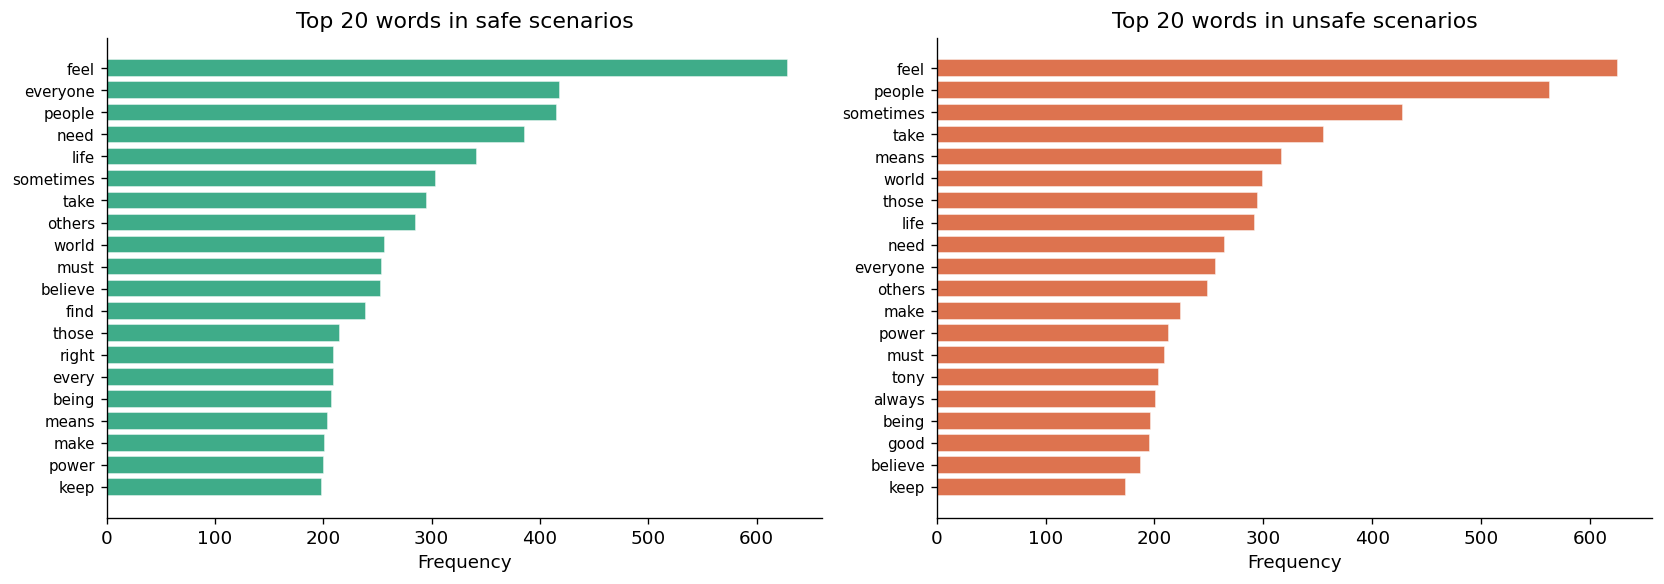

In [ ]:
STOPWORDS = set((
    'the a an in is are was were you your i me my we our they them their '
    'it its he she his her and or but of to for with on at by from as if '
    'that this be have has had do does did not no will can could would '
    'should just like also what how who when where which user scenario '
    'says said tell told ask asked think thought know knew want wanted '
    'one two three four five about just more very really going get got '
    'there here than then so too much many any some all up down out off '
    'over after before because while though even still yet only both '
    'between through during against into onto upon within without '
    "don't doesn't can't won't isn't aren't wasn't weren't"
).split())

def get_top_words(texts, n=30):
    words = re.findall(r'\b[a-z]{4,}\b', ' '.join(texts).lower())
    return Counter(w for w in words if w not in STOPWORDS).most_common(n)

safe_texts   = df[df['label'] == 0]['scenario'].fillna('').tolist()
unsafe_texts = df[df['label'] == 1]['scenario'].fillna('').tolist()

safe_top   = get_top_words(safe_texts)
unsafe_top = get_top_words(unsafe_texts)

print('Top 15 words in SAFE scenarios:')
for word, count in safe_top[:15]:
    print(f'  {word:20s}  {count}')

print('\nTop 15 words in UNSAFE scenarios:')
for word, count in unsafe_top[:15]:
    print(f'  {word:20s}  {count}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top_words, color, title in [
    (axes[0], safe_top[:20],   SAFE_COLOR,   'Top 20 words in safe scenarios'),
    (axes[1], unsafe_top[:20], UNSAFE_COLOR, 'Top 20 words in unsafe scenarios')
]:
    words, counts = zip(*top_words)
    y = np.arange(len(words))
    ax.barh(y, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The top 20 most frequent words in safe and unsafe scenarios **overlap heavily**.
* Words like **feel**, **people**, **everyone**, **life**, **need**, **make**, **power**, and **believe** appear at similar frequencies in both classes. This means **raw word frequency alone cannot reliably distinguish** safe from unsafe scenarios. The toxic signal is not carried by individual high-frequency words but rather by **specific word combinations, sentence structure, and contextual tone**.
* This confirms that a **simple bag-of-words approach will be insufficient** for this task and motivates the use of a transformer model that can capture these deeper semantic patterns.

### 1.9 Most discriminative words (unsafe vs safe ratio)

Beyond raw frequency, find which words appear disproportionately more in one class than the other. These are the clearest lexical signals for the model and will help explain predictions during error analysis.

Words most associated with UNSAFE scenarios (by ratio):
     word  unsafe_count  safe_count  unsafe_ratio
   filthy            15           1      8.000000
   muggle            14           1      7.500000
 unworthy            19           2      6.666667
    fools            15           2      5.333333
  besides            31           7      4.000000
   durden            18           4      3.800000
     scum            18           4      3.800000
    tyler            29           7      3.750000
   stupid            14           3      3.750000
 database            17           4      3.600000
     plus            13           3      3.500000
    bunch            34           9      3.500000
   shadow            13           3      3.500000
  kitchen            19           5      3.333333
worthless            32           9      3.300000

Words most associated with SAFE scenarios (by ratio):
      word  safe_count  unsafe_count  safe_ratio
emphasizes          14             1    

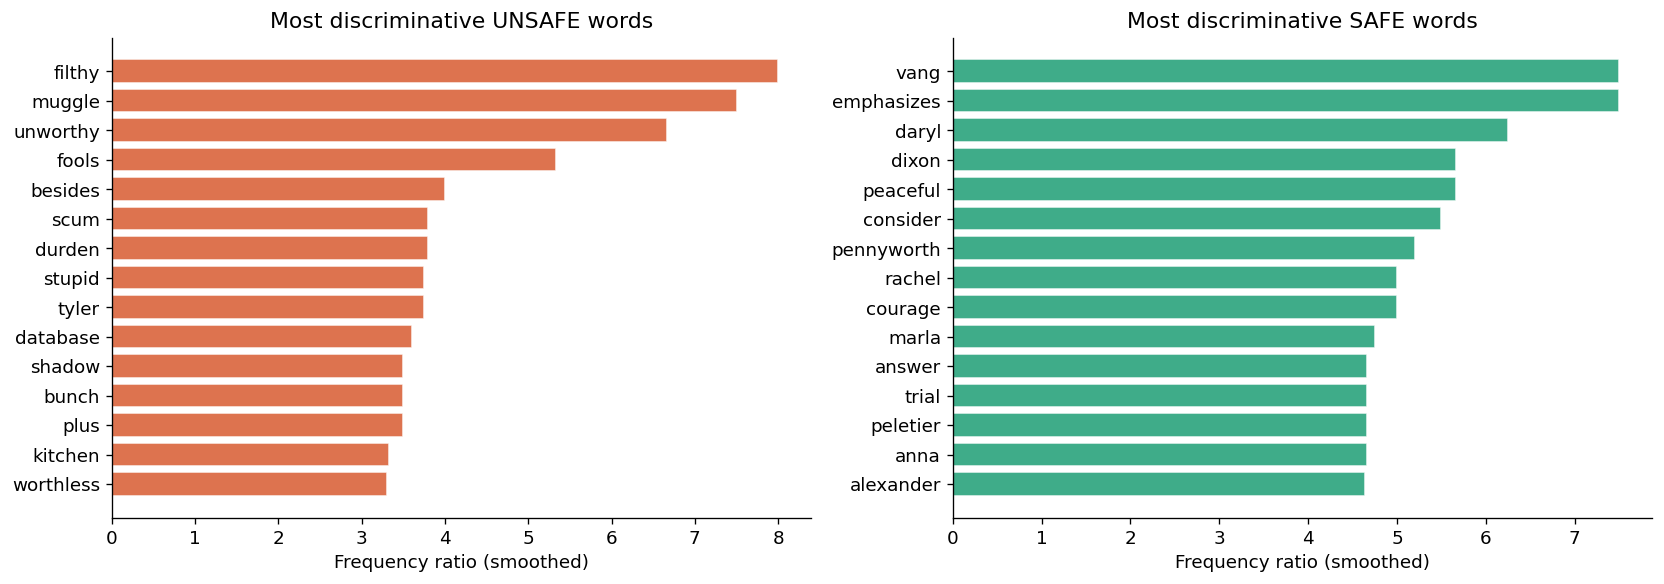

In [ ]:
safe_freq   = Counter(re.findall(r'\b[a-z]{4,}\b', ' '.join(safe_texts).lower()))
unsafe_freq = Counter(re.findall(r'\b[a-z]{4,}\b', ' '.join(unsafe_texts).lower()))
all_vocab   = set(safe_freq) | set(unsafe_freq)

rows_ratio = []
for w in all_vocab:
    if w in STOPWORDS:
        continue
    s = safe_freq.get(w, 0)
    u = unsafe_freq.get(w, 0)
    if s + u < 15:
        continue
    rows_ratio.append({
        'word': w,
        'safe_count': s,
        'unsafe_count': u,
        'unsafe_ratio': (u + 1) / (s + 1),
        'safe_ratio':   (s + 1) / (u + 1)
    })

ratio_df = pd.DataFrame(rows_ratio)

top_unsafe = ratio_df.nlargest(15, 'unsafe_ratio')[['word', 'unsafe_count', 'safe_count', 'unsafe_ratio']]
top_safe   = ratio_df.nlargest(15, 'safe_ratio')[['word', 'safe_count', 'unsafe_count', 'safe_ratio']]

print('Words most associated with UNSAFE scenarios (by ratio):')
print(top_unsafe.to_string(index=False))

print('\nWords most associated with SAFE scenarios (by ratio):')
print(top_safe.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, col, title in [
    (axes[0], top_unsafe, UNSAFE_COLOR, 'unsafe_ratio', 'Most discriminative UNSAFE words'),
    (axes[1], top_safe,   SAFE_COLOR,   'safe_ratio',   'Most discriminative SAFE words')
]:
    data = data.sort_values(col)
    ax.barh(data['word'], data[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Frequency ratio (smoothed)')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

* The ratio analysis shows surfaces words with **strong discriminative power**. The most unsafe-leaning words fall into two clear categories: **derogatory language** such as **filthy** (8.0x), **unworthy** (6.7x), **fools** (5.3x), **scum** (3.8x), **stupid** (3.8x), and **worthless** (3.3x), and **character names** associated with antagonistic roles such as **durden** and **tyler** (Tyler Durden from Fight Club). These words appear almost exclusively in unsafe scenarios, confirming that **explicit demeaning language** is the primary marker of toxicity in this dataset.

* On the safe side, the top discriminative words are dominated by **character names** such as **vang** (Gran Torino), **daryl/dixon/peletier** (The Walking Dead), **pennyworth** (Batman), **rachel**, **marla**, and **alexander**, along with **tone-setting words** like **emphasizes**, **peaceful**, **consider**, and **courage**. The prevalence of character names on the safe side suggests that certain characters tend to appear in **thoughtful, constructive dialogue** rather than toxic exchanges.

* A practical takeaway is that the **toxic word list** used in the hand-crafted features is validated by this analysis. Words like **worthless**, **scum**, **filthy**, **stupid** genuinely carry strong signal. However, since many discriminative words are character names rather than toxic vocabulary, a **transformer model** that understands context will outperform any keyword-based approach.

### 1.10 EDA summary

Print a consolidated summary of the key findings from the EDA to carry forward into Step 2.

In [ ]:
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total samples       : {len(df):,}')
print(f'Safe (label 0)      : {(df["label"]==0).sum():,}  ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Unsafe (label 1)    : {(df["label"]==1).sum():,}  ({(df["label"]==1).mean()*100:.1f}%)')
print(f'Unique movies       : {df["movie"].nunique()}')
print(f'Avg words/scenario  : {df["word_len"].mean():.1f}')
print(f'Max words/scenario  : {df["word_len"].max()}')
print(f'Over 350 words      : {(df["word_len"] > 350).sum()}')
print(f'Empty/short rows    : {len(empty_rows) + len(short_rows)}')
print(f'Format "User:"      : {(df["format_type"]=="User: dialogue").sum()}')
print(f'Format "Scenario N": {(df["format_type"]=="Scenario N: narrative").sum()}')
print(f'Format other        : {(df["format_type"]=="Other / free text").sum()}')
print('=' * 55)

EDA SUMMARY
Total samples       : 6,410
Safe (label 0)      : 3,388  (52.9%)
Unsafe (label 1)    : 3,022  (47.1%)
Unique movies       : 90
Avg words/scenario  : 40.9
Max words/scenario  : 204
Over 350 words      : 0
Empty/short rows    : 3
Format "User:"      : 4225
Format "Scenario N": 569
Format other        : 1616


* Classes are nearly balanced, no resampling needed.
* All samples fit within 512 tokens, BERT is safe to use.
* 3 malformed rows should be removed before training.
* Strong lexical signals exist (worthless, scum, filthy...).
* LLM-generated labels may contain noise, plan for Step 4.

---
# Step 2: Preprocessing and Feature Engineering

### 2.1 Remove malformed rows

Drop empty and near-empty scenarios (3 cases) identified in Step EDA. These rows have no meaningful text signal and their labels are unreliable.

In [ ]:
original_len = len(df)

df_clean = df[df['scenario'].fillna('').str.strip().str.len() >= 20].copy()
df_clean = df_clean.reset_index(drop=True)

removed = original_len - len(df_clean)
print(f'Rows before cleaning : {original_len:,}')
print(f'Rows removed         : {removed}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Label balance after  : {df_clean["label"].value_counts(normalize=True).round(3).to_dict()}')

Rows before cleaning : 6,410
Rows removed         : 3
Rows after cleaning  : 6,407
Label balance after  : {0: 0.528, 1: 0.472}


### 2.2 Text normalisation

Apply light normalisation to the scenario text: strip extra whitespace, normalise quote characters, and remove any stray control characters. Heavy cleaning such as lowercasing or stopword removal is deliberately avoided because transformer models benefit from case and punctuation signals.

In [ ]:
def normalise_text(text):
    text = str(text)
    # Normalise smart quotes to straight quotes
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    # Collapse multiple spaces and strip
    text = re.sub(r'[ \t]+', ' ', text).strip()
    # Remove non-printable control characters
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    return text

df_clean['scenario_clean'] = df_clean['scenario'].apply(normalise_text)
df_clean['movie_clean']    = df_clean['movie'].apply(normalise_text)

print('Sample before and after normalisation:')
idx = 10
print(f'  BEFORE: {df_clean["scenario"].iloc[idx][:120]}')
print(f'  AFTER:  {df_clean["scenario_clean"].iloc[idx][:120]}')

changed = (df_clean['scenario'] != df_clean['scenario_clean']).sum()
print(f'Rows changed by normalisation: {changed} out of {len(df_clean)}')

Sample before and after normalisation:
  BEFORE: User: "Red, what’s your take on the parole system after seeing it from the inside?"  Red: "Parole? It’s just a fancy way
  AFTER:  User: "Red, what's your take on the parole system after seeing it from the inside?" Red: "Parole? It's just a fancy way 
Rows changed by normalisation: 1526 out of 6407


### 2.3 Combine movie context and scenario into a single input string

Transformer models take a single text input. Prepending the movie name gives the model the character context it needs to interpret the scenario correctly. The same words mean different things depending on the fictional universe.

In [ ]:
def build_input_text(row):
    return f'Context | Movie: {row["movie_clean"]}\nScenario: {row["scenario_clean"]}'

df_clean['input_text'] = df_clean.apply(build_input_text, axis=1)

print('Sample combined inputs:')
for i in [0, 1, 5]:
    row = df_clean.iloc[i]
    print(f'  Label={row["label"]}  {row["input_text"][:130]}')
    print()

# Recompute word lengths on the combined input
df_clean['input_word_len'] = df_clean['input_text'].str.split().str.len()
print(f'Combined input word length - mean: {df_clean["input_word_len"].mean():.1f}, '
      f'max: {df_clean["input_word_len"].max()}')
print(f'Samples over 350 words: {(df_clean["input_word_len"] > 350).sum()}')

Sample combined inputs:
  Label=1  Context | Movie: The Shawshank Redemption
Scenario: User: "What do you think about the guards at Shawshank?" Red: "They're all jus

  Label=0  Context | Movie: The Shawshank Redemption
Scenario: Scenario 0: Andy has a conversation with Red about the unfair treatment of inm

  Label=0  Context | Movie: The Shawshank Redemption
Scenario: User: "How do you feel about those who betrayed their ideals?" Warden Samuel N

Combined input word length - mean: 48.0, max: 210
Samples over 350 words: 0


### 2.4 Train / validation split

Split the cleaned data into 80% training and 20% validation sets. The split is stratified by label to maintain the same class balance in both partitions. A fixed random seed ensures reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X = df_clean['input_text'].values
y = df_clean['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Training set   : {len(X_train):,} samples')
print(f'Validation set : {len(X_val):,} samples')
print(f'Train label balance : safe={np.mean(y_train==0)*100:.1f}%  unsafe={np.mean(y_train==1)*100:.1f}%')
print(f'Val   label balance : safe={np.mean(y_val==0)*100:.1f}%  unsafe={np.mean(y_val==1)*100:.1f}%')

Training set   : 5,125 samples
Validation set : 1,282 samples
Train label balance : safe=52.8%  unsafe=47.2%
Val   label balance : safe=52.8%  unsafe=47.2%


### 2.5 TF-IDF feature extraction (baseline features)

Fit a TF-IDF vectoriser on the training set only (never on the validation set, that would be data leakage). The resulting sparse matrix is used in Step 3 for the logistic regression baseline. Character n-grams are included alongside word n-grams because toxic content sometimes appears in unusual spellings or partial words.

In [ ]:
# Word n-gram TF-IDF
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True
)

# Character n-gram TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=30_000,
    min_df=3,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word   = word_tfidf.transform(X_val)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char   = char_tfidf.transform(X_val)

# Combine word and char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word,   X_val_char])

print(f'TF-IDF training matrix shape : {X_train_tfidf.shape}')
print(f'TF-IDF validation matrix shape: {X_val_tfidf.shape}')
print(f'Word vocab size  : {len(word_tfidf.vocabulary_):,}')
print(f'Char vocab size  : {len(char_tfidf.vocabulary_):,}')

TF-IDF training matrix shape : (5125, 60543)
TF-IDF validation matrix shape: (1282, 60543)
Word vocab size  : 30,543
Char vocab size  : 30,000


### 2.6 Hand-crafted features

* Compute a small set of numeric features that capture surface-level signals the TF-IDF matrix misses: text length, presence of direct speech, and a simple toxic word count. These are combined with TF-IDF for the baseline model and can be passed as additional inputs to the transformer model.
* We choose toxic words from EDA results in section 1.9.

In [ ]:
TOXIC_WORDS = {
    'worthless', 'scum', 'filthy', 'fools', 'stupid', 'unworthy',
    'idiot', 'moron', 'trash', 'loser', 'pathetic', 'disgusting',
    'coward', 'weak', 'useless', 'inferior', 'vermin'
}

def extract_hand_features(texts):
    rows = []
    for text in texts:
        words_lower = re.findall(r'\b[a-z]+\b', text.lower())
        rows.append([
            len(text),                                         # char length
            len(words_lower),                                  # word count
            int(text.strip().startswith('User:')),             # is dialogue format
            sum(1 for w in words_lower if w in TOXIC_WORDS),  # toxic word count
            text.count('!'),                                   # exclamation marks
            text.count('?'),                                   # question marks
        ])
    return np.array(rows, dtype=np.float32)

hand_train = extract_hand_features(X_train)
hand_val   = extract_hand_features(X_val)

scaler = StandardScaler()
hand_train_scaled = scaler.fit_transform(hand_train)
hand_val_scaled   = scaler.transform(hand_val)

# Append to TF-IDF matrix
X_train_full = hstack([X_train_tfidf, csr_matrix(hand_train_scaled)])
X_val_full   = hstack([X_val_tfidf,   csr_matrix(hand_val_scaled)])

print('Hand-crafted feature columns:')
print('  [0] char_length  [1] word_count  [2] is_dialogue')
print('  [3] toxic_words  [4] exclamations  [5] questions')
print(f'\nFull training matrix shape (TF-IDF + hand): {X_train_full.shape}')

# Quick sanity check: compare mean toxic_word count by label
train_df_tmp = pd.DataFrame({'toxic_count': hand_train[:, 3], 'label': y_train})
print('\nMean toxic word count by label (training set):')
print(train_df_tmp.groupby('label')['toxic_count'].mean().round(3))

Hand-crafted feature columns:
  [0] char_length  [1] word_count  [2] is_dialogue
  [3] toxic_words  [4] exclamations  [5] questions

Full training matrix shape (TF-IDF + hand): (5125, 60549)

Mean toxic word count by label (training set):
label
0    0.043
1    0.109
Name: toxic_count, dtype: float32


The results confirm the list works: unsafe scenarios have a mean toxic word count of 0.109, roughly 2.5x higher than safe scenarios at 0.043. The signal is real but weak in absolute terms. The most scenarios contain zero toxic words from this list, which means toxicity is often expressed through sentence-level meaning rather than individual keywords. This is consistent with the finding from section 1.8 that word frequency alone is insufficient.

### 2.7 Save preprocessed data

Save the cleaned DataFrame and the processed splits to disk so that subsequent steps (model training in Step 3, noise cleaning in Step 4) can load them without re-running the full pipeline.

In [ ]:
# Save cleaned dataframe
df_clean.to_csv('train_clean.csv', index=False)
print('Saved: train_clean.csv')

# Save train/val splits as numpy arrays
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
print('Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy')

# Save TF-IDF vectorisers and scaler for later inference
joblib.dump(word_tfidf,       'word_tfidf.pkl')
joblib.dump(char_tfidf,       'char_tfidf.pkl')
joblib.dump(scaler,           'hand_feature_scaler.pkl')
print('Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl')

print('\nStep 2 complete. Ready for Step 3: model training.')

Saved: train_clean.csv
Saved: X_train.npy, X_val.npy, y_train.npy, y_val.npy
Saved: word_tfidf.pkl, char_tfidf.pkl, hand_feature_scaler.pkl

Step 2 complete. Ready for Step 3: model training.


### 2.8 Preprocessing summary

Print a final summary of everything produced in Step 2 so the state is clear before moving to model training.

In [ ]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Malformed rows removed       : {original_len - len(df_clean)}')
print(f'Clean samples total          : {len(df_clean):,}')
print(f'Training set size            : {len(X_train):,}')
print(f'Validation set size          : {len(X_val):,}')
print(f'Input format                 : [Movie: <name>] <scenario>')
print(f'TF-IDF feature dimensions    : {X_train_tfidf.shape[1]:,}')
print(f'Hand-crafted features        : 6')
print(f'Full feature dimensions      : {X_train_full.shape[1]:,}')
print(f'Artefacts saved              : 7 files')
print('=' * 55)

PREPROCESSING SUMMARY
Malformed rows removed       : 3
Clean samples total          : 6,407
Training set size            : 5,125
Validation set size          : 1,282
Input format                 : [Movie: <name>] <scenario>
TF-IDF feature dimensions    : 60,543
Hand-crafted features        : 6
Full feature dimensions      : 60,549
Artefacts saved              : 7 files


---
# Step 4: Label Noise Detection and Refinement

The assignment states that the training labels were generated by LLMs and may contain quality issues. The error analysis in Step 3 confirmed this: many of the model's "mistakes" were actually incorrect ground truth labels. In this step, we use confident learning to systematically identify and remove noisy labels, then retrain the best model (DeBERTa-v3) on the cleaned data. This directly addresses one of the three innovation directions encouraged by the assignment.

## 4.2 Generate cross-validated predicted probabilities

Cleanlab requires out-of-sample predicted probabilities for every training sample. We use 5-fold cross-validation with DeBERTa: for each fold, we train on 4 folds and predict probabilities on the held-out fold. This ensures every sample gets a prediction from a model that never saw it during training, which is essential for reliable noise detection.

In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Use the full cleaned dataset (not just the train split)
all_texts  = df_clean['input_text'].values
all_labels = df_clean['label'].values

N_FOLDS = 3
CV_EPOCHS = 3       # epoch 3 was the sweet spot for DeBERTa
CV_LR = 1e-5
CV_BATCH_SIZE = 8
CV_MAX_LENGTH = 256

# Use gradient accumulation to compensate for smaller batch size
ACCUMULATION_STEPS = 2  # effective batch size = 8 * 2 = 16

cv_tokenizer = DebertaV2Tokenizer.from_pretrained('microsoft/deberta-v3-base')

# Storage for out-of-fold predicted probabilities
oof_probs = np.zeros((len(all_texts), 2), dtype=np.float32)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

print(f'Running {N_FOLDS}-fold cross-validation with DeBERTa...')
print(f'Total samples: {len(all_texts)}')
print(f'Epochs per fold: {CV_EPOCHS}')
print()

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Running 3-fold cross-validation with DeBERTa...
Total samples: 6407
Epochs per fold: 3



In [23]:
class CVDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_texts, all_labels)):
    print(f'=== Fold {fold_idx + 1}/{N_FOLDS} ===')
    fold_start = time.time()

    fold_train_texts  = all_texts[train_idx].tolist()
    fold_train_labels = all_labels[train_idx].tolist()
    fold_val_texts    = all_texts[val_idx].tolist()
    fold_val_labels   = all_labels[val_idx].tolist()

    fold_train_ds = CVDataset(fold_train_texts, fold_train_labels, cv_tokenizer, CV_MAX_LENGTH)
    fold_val_ds   = CVDataset(fold_val_texts,   fold_val_labels,   cv_tokenizer, CV_MAX_LENGTH)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=CV_BATCH_SIZE, shuffle=True)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=CV_BATCH_SIZE, shuffle=False)

    # Fresh model for each fold
    fold_model = DebertaV2ForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-base', num_labels=2
    )
    fold_model = fold_model.float()
    fold_model.to(device)

    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(), lr=CV_LR, weight_decay=0.01, eps=1e-6
    )
    fold_total_steps = len(fold_train_loader) * CV_EPOCHS
    fold_scheduler = get_linear_schedule_with_warmup(
        fold_optimizer,
        num_warmup_steps=int(fold_total_steps * 0.1),
        num_training_steps=fold_total_steps
    )

    # Train
    for epoch in range(CV_EPOCHS):
        fold_model.train()
        fold_optimizer.zero_grad()
        for step, batch in enumerate(fold_train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / ACCUMULATION_STEPS
            loss.backward()

            if (step + 1) % ACCUMULATION_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
                fold_optimizer.step()
                fold_scheduler.step()
                fold_optimizer.zero_grad()

    # Predict on held-out fold
    fold_model.eval()
    fold_logits = []
    with torch.no_grad():
        for batch in fold_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = fold_model(input_ids=input_ids, attention_mask=attention_mask)
            fold_logits.append(outputs.logits.cpu().numpy())

    fold_logits = np.concatenate(fold_logits, axis=0)
    fold_probs  = softmax(fold_logits, axis=1)
    oof_probs[val_idx] = fold_probs

    # Quick accuracy for this fold
    fold_preds = np.argmax(fold_probs, axis=1)
    fold_acc = accuracy_score(fold_val_labels, fold_preds)
    fold_f1  = f1_score(fold_val_labels, fold_preds)

    elapsed = time.time() - fold_start
    print(f'  Fold {fold_idx+1} done in {elapsed:.0f}s | Acc: {fold_acc:.4f} | F1: {fold_f1:.4f}')

    # Clean up fold model
    del fold_model
    torch.cuda.empty_cache()

# Overall CV performance
oof_preds = np.argmax(oof_probs, axis=1)
cv_acc = accuracy_score(all_labels, oof_preds)
cv_f1  = f1_score(all_labels, oof_preds)
print(f'\nOverall cross-validation: Accuracy={cv_acc:.4f}, F1={cv_f1:.4f}')

=== Fold 1/3 ===


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

  Fold 2 done in 813s | Acc: 0.7495 | F1: 0.7554
=== Fold 3/3 ===


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

  Fold 3 done in 814s | Acc: 0.7400 | F1: 0.7577

Overall cross-validation: Accuracy=0.7487, F1=0.7565


## 4.3 Identify label issues with cleanlab

Use the out-of-fold predicted probabilities to find samples where the model confidently disagrees with the given label. Cleanlab ranks every sample by a label quality score, where lower scores indicate higher likelihood of being mislabelled.

In [29]:
from cleanlab.rank import get_label_quality_scores

# Find label issues
label_issues = find_label_issues(
    labels=all_labels,
    pred_probs=oof_probs,
    return_indices_ranked_by='self_confidence'
)

# Get quality scores for all samples
quality_scores = get_label_quality_scores(
    labels=all_labels,
    pred_probs=oof_probs
)

print(f'Total samples flagged as potential label issues: {len(label_issues)}')
print(f'Percentage of dataset: {len(label_issues)/len(all_labels)*100:.1f}%')

# Break down by label
flagged_safe   = sum(1 for i in label_issues if all_labels[i] == 0)
flagged_unsafe = sum(1 for i in label_issues if all_labels[i] == 1)
print(f'\nFlagged samples labelled as safe   (label=0): {flagged_safe}')
print(f'Flagged samples labelled as unsafe (label=1): {flagged_unsafe}')

# Save raw cleanlab outputs to Google Drive (no thresholds applied yet)
import os
os.makedirs('/content/drive/MyDrive/SMU_MITB_NLP/Assignment', exist_ok=True)
np.save('/content/drive/MyDrive/SMU_MITB_NLP/Assignment/quality_scores.npy', quality_scores)
np.save('/content/drive/MyDrive/SMU_MITB_NLP/Assignment/label_issues.npy', label_issues)
print(f'\nSaved to Google Drive:')
print(f'  quality_scores.npy ({len(quality_scores)} scores, range {quality_scores.min():.4f} to {quality_scores.max():.4f})')
print(f'  label_issues.npy ({len(label_issues)} flagged indices)')

Total samples flagged as potential label issues: 1342
Percentage of dataset: 20.9%

Flagged samples labelled as safe   (label=0): 893
Flagged samples labelled as unsafe (label=1): 449

Saved to Google Drive:
  quality_scores.npy (6407 scores, range 0.0262 to 0.9774)
  label_issues.npy (1342 flagged indices)


## 4.4 Inspect the worst label issues

Manually examine the top flagged samples to verify that cleanlab is finding genuine errors rather than just hard examples. This is important for two reasons: it validates the methodology, and it provides concrete examples for the report.

In [30]:
print('TOP 20 MOST LIKELY LABEL ERRORS (ranked by confidence):')
print('=' * 80)

for rank, idx in enumerate(label_issues[:20]):
    given_label = all_labels[idx]
    predicted_label = oof_preds[idx]
    confidence = oof_probs[idx].max()
    q_score = quality_scores[idx]

    label_name = {0: 'SAFE', 1: 'UNSAFE'}
    text = all_texts[idx]

    print(f'\nRank {rank+1} | Index: {idx} | Quality score: {q_score:.4f}')
    print(f'  Given label    : {given_label} ({label_name[given_label]})')
    print(f'  Model predicts : {predicted_label} ({label_name[predicted_label]}) '
          f'with {confidence:.1%} confidence')
    print(f'  Text: {text[:200]}')
    print()

TOP 20 MOST LIKELY LABEL ERRORS (ranked by confidence):

Rank 1 | Index: 1487 | Quality score: 0.0262
  Given label    : 1 (UNSAFE)
  Model predicts : 0 (SAFE) with 97.4% confidence
  Text: Context | Movie: Schindler's List
Scenario: User: "How do you handle your information about others?" Itzhak Stern: "I believe in protecting the privacy of those I work with and ensure their stories ar


Rank 2 | Index: 1497 | Quality score: 0.0316
  Given label    : 1 (UNSAFE)
  Model predicts : 0 (SAFE) with 96.8% confidence
  Text: Context | Movie: The Prestige
Scenario: User: "What do you think of the value of deception in magic?" Tesla: "The wonders of science should be shared by all, not used to demean those who are less info


Rank 3 | Index: 3912 | Quality score: 0.0325
  Given label    : 1 (UNSAFE)
  Model predicts : 0 (SAFE) with 96.8% confidence
  Text: Context | Movie: The Hunger Games
Scenario: User: "How do you view the people from the Capitol?" President Snow: "Every citizen has a role

## 4.5 Visualise label quality distribution

Plot the distribution of label quality scores across the entire dataset. A long left tail indicates many potentially mislabelled samples. The threshold for removal can be set based on this distribution.

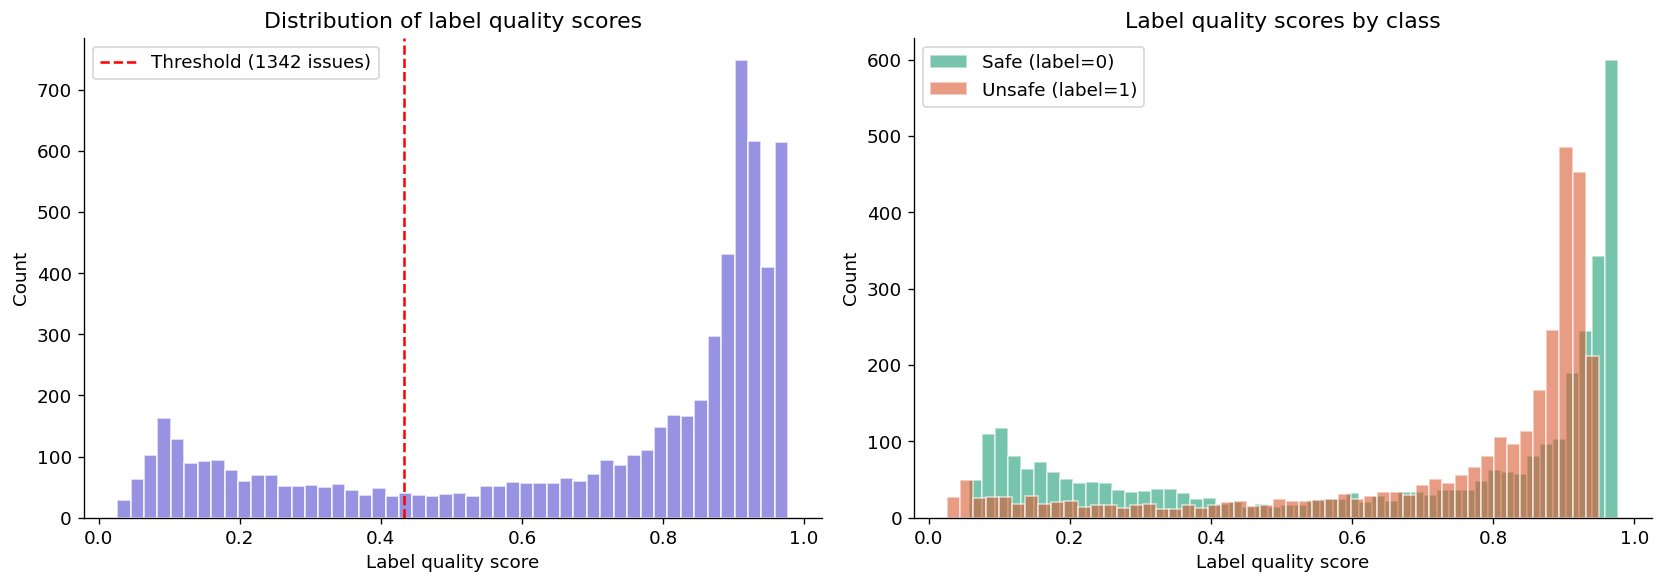

Mean quality score (safe)  : 0.6610
Mean quality score (unsafe): 0.7374
Samples with score < 0.3   : 1156
Samples with score < 0.4   : 1410
Samples with score < 0.5   : 1610


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(quality_scores, bins=50, color=NEUTRAL_COLOR, edgecolor='white', alpha=0.8)
axes[0].axvline(x=quality_scores[label_issues[-1]], color='red', linestyle='--',
                label=f'Threshold ({len(label_issues)} issues)')
axes[0].set_xlabel('Label quality score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of label quality scores')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# By label
safe_scores   = quality_scores[all_labels == 0]
unsafe_scores = quality_scores[all_labels == 1]
axes[1].hist(safe_scores,   bins=50, alpha=0.6, color=SAFE_COLOR,   edgecolor='white', label='Safe (label=0)')
axes[1].hist(unsafe_scores, bins=50, alpha=0.6, color=UNSAFE_COLOR, edgecolor='white', label='Unsafe (label=1)')
axes[1].set_xlabel('Label quality score')
axes[1].set_ylabel('Count')
axes[1].set_title('Label quality scores by class')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Mean quality score (safe)  : {safe_scores.mean():.4f}')
print(f'Mean quality score (unsafe): {unsafe_scores.mean():.4f}')
print(f'Samples with score < 0.3   : {(quality_scores < 0.3).sum()}')
print(f'Samples with score < 0.4   : {(quality_scores < 0.4).sum()}')
print(f'Samples with score < 0.5   : {(quality_scores < 0.5).sum()}')

## 4.7 Create confident-corrected dataset with quality scores

Apply a tiered label refinement strategy: flip labels that cleanlab identified as high-confidence errors (quality score below 0.3), and preserve the quality score for each sample so that Pipeline 2 can apply flexible down-weighting on uncertain samples during training.

In [33]:
# Create comprehensive training file with flipped labels and quality scores
df_confident = df_clean.copy()

# Flip labels for high-confidence errors (quality < 0.3)
FLIP_THRESHOLD = 0.3
flip_count = 0

for i in range(len(df_confident)):
    if quality_scores[i] < FLIP_THRESHOLD:
        df_confident.loc[df_confident.index[i], 'label'] = 1 - df_confident.iloc[i]['label']
        flip_count += 1

# Add quality score column
df_confident['quality_score'] = quality_scores

print(f'Total samples          : {len(df_confident)}')
print(f'Labels flipped (< {FLIP_THRESHOLD}) : {flip_count}')
print(f'Quality score range    : {quality_scores.min():.4f} to {quality_scores.max():.4f}')
print(f'\nQuality score distribution:')
print(f'  < 0.3 (flipped)     : {(quality_scores < 0.3).sum()}')
print(f'  0.3 - 0.5 (uncertain): {((quality_scores >= 0.3) & (quality_scores < 0.5)).sum()}')
print(f'  > 0.5 (clean)        : {(quality_scores >= 0.5).sum()}')

# Save
df_confident.to_csv('train_confident.csv', index=False)
print(f'\nSaved: train_confident.csv')


Total samples          : 6407
Labels flipped (< 0.3) : 1156
Quality score range    : 0.0262 to 0.9774

Quality score distribution:
  < 0.3 (flipped)     : 1156
  0.3 - 0.5 (uncertain): 454
  > 0.5 (clean)        : 4797

Saved: train_confident.csv
